this one is for Markerballs which simoulate CSS equipment in PLSCADD

In [13]:
# paths
from pathlib import Path 
workdir = Path("C:\\Users\\Igor.Bertyaev.APD\\OneDrive - APD\\_IGOR\\__NZ\\Z_APD01040_HLY-OTA-A Reconductoring\\mb")
mb_list = workdir / "CSS-HLY-OTAA_calcs_v1.xlsx"


load pandas and read xls  - change the range if needed !

In [14]:
import pandas as pd

# read tab "Input", and the table B12:L26 - change the range if needed !

df = pd.read_excel(mb_list, sheet_name="Input", usecols="B:M", skiprows=10, nrows=15)

# name the columns
df.columns = ["num1", "MB", "dia1", "spacing", "weight", "area", "dia2", "dia_pls", "num2", "file_name", "color", "path"]

# set index to the first column
df.set_index("num1", inplace=True)

#print index and columns
print("Index:")
print(df.index)
print("\nColumns:") 
print(df.columns)   


Index:
Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 99, 100, 0], dtype='int64', name='num1')

Columns:
Index(['MB', 'dia1', 'spacing', 'weight', 'area', 'dia2', 'dia_pls', 'num2',
       'file_name', 'color', 'path'],
      dtype='object')


In [15]:
#test print
print(df.loc[100, "MB"], " - ", df.loc[100, "weight"])

Go-kart  -  1962.0


In [16]:
#example of mb file (raw text)
mb_file_example = r"""TYPE='MARKER BALL FILE' VERSION='4' UNITS='INTERNAL' SOURCE='PLS-CADD Version 21.00' USER='Alliance Power & Data - Australia' FILENAME='C:\PLS\TP_TRK-DEV-B\cables\2-Rope-n-Block_5m.mar'
Rope and Block - 5m
2
21.5900 0.0000 0.0000 0.6333 0.0000 0 0 16744448 16744448 1.0000 0.000000 0.000000
"""
# first_row = r"TYPE='MARKER BALL FILE' VERSION='4' UNITS='INTERNAL' SOURCE='PLS-CADD Version 21.00' USER='Alliance Power & Data - Australia' FILENAME="
# #lets find variables in the mb file example
# mb_file_name = Path(mb_file_example.splitlines()[0].split("FILENAME='")[1].split("'")[0])

# second line is MB name
# third line is MB number
# fourth line is MB data (weight, ?0, ?0, dia, ?0,?0,?0, color, color2, ?1, ?0, ?0)


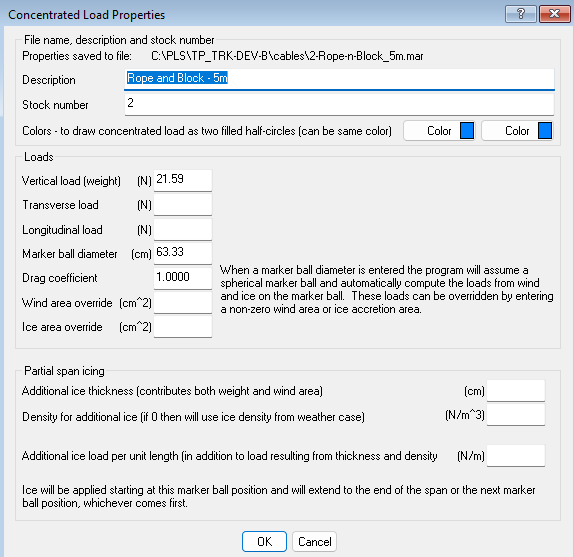

next create mb files (each row in the table) using mb_file_example as an template

In [17]:
# make a function to create mb file for any row in the dataframe
def create_mb_file(df):
    col_blue = '16744448 16744448'
    col_grey = '8421504 8421504'
    col_pink = '16711935 16711935'
    col_white = '16777215 16777215'
    col_final = col_white  # default color

    first_row = r"TYPE='MARKER BALL FILE' VERSION='4' UNITS='INTERNAL' SOURCE='PLS-CADD Version 21.00' USER='Alliance Power & Data - Australia' FILENAME="
    
    for index, row in df.iterrows():
        color = row['color'].lower()
        if color == 'blue':
            col_final = col_blue
        elif color == 'grey':
            col_final = col_grey
        elif color == 'pink':
            col_final = col_pink
        else:
            col_final = col_white

        first_line = f"{first_row}'{row['path']}'" # first stroke
        second_line = f"{row['MB']}" # second stroke - marker ball name
        third_line = f"{row['num2']}" # third stroke - marker ball number
        fourth_line = f"{row['weight']:.4f} 0.0000 0.0000 {row['dia_pls']/100:.4f} 0.0000 0 0 {col_final} 1.0000 0.000000 0.000000" # fourth stroke

        #creating the file
        with open(f"{row['file_name']}", "w") as f:
            f.write(first_line + "\n")
            f.write(second_line + "\n")
            f.write(third_line + "\n")
            f.write(fourth_line + "\n")

In [18]:
# run the function to create mb files
create_mb_file(df)